Total time profiles: 49. Plotting 16: t_0.0s, t_0.05s, t_0.82s, t_2.89s, t_6.18s, t_10.3s, t_20.2s, t_33.39s, t_53.17s, t_86.15s, t_165.28s, t_323.56s, t_692.88s, t_798.39s, t_1009.43s, t_1042.0s

Plot saved successfully as 'outputs/charge_radial_profiles_subplots.svg'


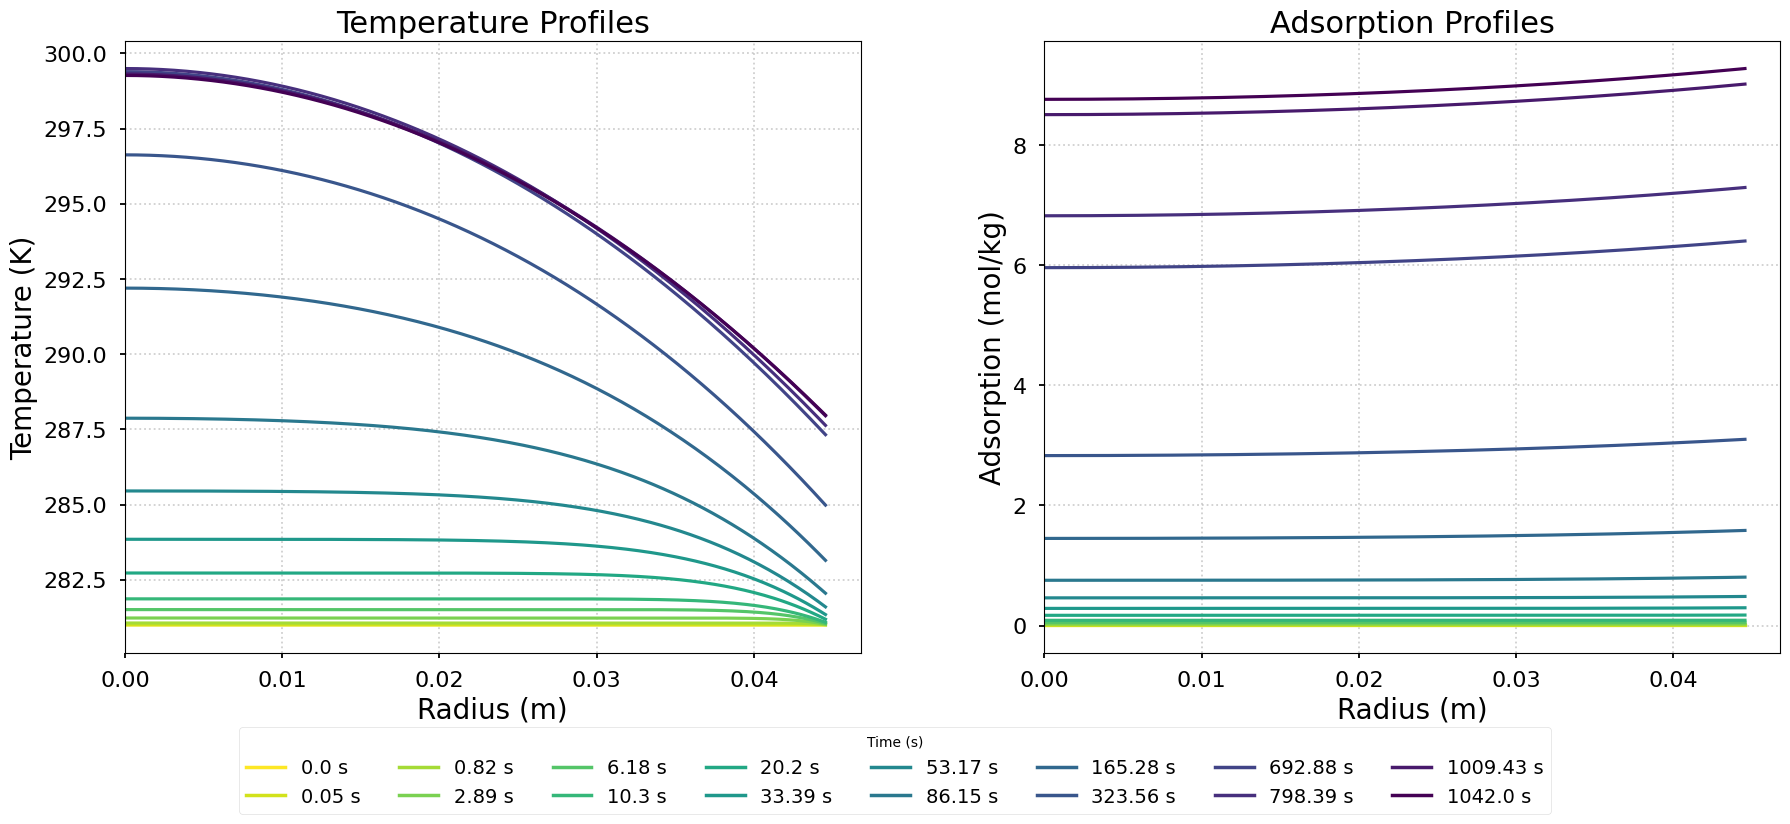

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

def create_beautiful_plot():
    """
    Loads temperature and adsorption data to create a
    publication-quality subplot figure showing radial profiles at
    different time steps.
    """
    
    folder = "outputs/"
    
    try:
        # --- 1. Load Data ---
        # Load the profile data. The structure is now:
        # Radius_m | t_0.0s | t_0.01s | ...
        df_temp = pd.read_csv(f'{folder}charge_temperature_profiles.csv')
        df_ads = pd.read_csv(f'{folder}charge_adsorption_profiles.csv')

        # This file is not strictly needed for this plot, as the time
        # information is in the columns of the other files.
        # df_time = pd.read_csv('timeseries_data.csv')

    except FileNotFoundError as e:
        print(f"Error: {e.filename} not found.")
        print("Please make sure 'temperature_profiles.csv' and 'adsorption_profiles.csv' are in the same directory.")
        sys.exit(1)
    except Exception as e:
        print(f"An error occurred loading the data: {e}")
        sys.exit(1)

    # --- 2. Process Data ---
    # Get the x-axis data (Radius)
    try:
        x_radius = df_temp['Radius_m']
        # Check that adsorption data has the same radius column
        if not df_ads['Radius_m'].equals(x_radius):
            print("Error: Radius columns in temperature and adsorption files do not match.")
            sys.exit(1)
    except KeyError:
        print("Error: 'Radius_m' column not found in CSV files.")
        sys.exit(1)

    # --- 3. Select Profiles to Plot (Time-based) ---
    # Get all time column names (e.g., 't_0.0s', 't_0.01s', ...)
    t_cols = [col for col in df_temp.columns if col.startswith('t_')]
    
    if not t_cols:
        print("Error: No time columns (starting with 't_') found in 'temperature_profiles.csv'.")
        sys.exit(1)

    # Select 16 profiles: 13 spaced evenly, PLUS the last 3 for pseudo-stationary state
    num_profiles_to_plot = 16
    num_stationary_points = 3
    num_linspace_points = num_profiles_to_plot - num_stationary_points # This will be 13

    if len(t_cols) < num_profiles_to_plot:
        print(f"Warning: Only {len(t_cols)} time profiles available. Plotting all of them.")
        indices = np.arange(len(t_cols))
    else:
        # Get 13 evenly spaced indices from the start up to the 4th-to-last point
        # (len(t_cols) - 1 - num_stationary_points) is the index of the 4th-to-last item
        stop_index = len(t_cols) - 1 - num_stationary_points
        linspace_indices = np.linspace(0, stop_index, num=num_linspace_points, dtype=int)
        
        # Get the indices for the last 3 time points
        last_three_indices = np.arange(len(t_cols) - num_stationary_points, len(t_cols))
        
        # Combine them. This gives exactly 16 unique indices.
        indices = np.concatenate((linspace_indices, last_three_indices))
    
    cols_to_plot = [t_cols[i] for i in indices]
    
    # Get a color for each selected profile using the 'viridis' colormap
    # Use viridis_r for a reversed map (Time 0 = bright, Final Time = dark)
    # We still use num_profiles_to_plot for the color map length
    colors = plt.cm.viridis_r(np.linspace(0, 1, num_profiles_to_plot))

    print(f"Total time profiles: {len(t_cols)}. Plotting {len(cols_to_plot)}: {', '.join(cols_to_plot)}")

    # --- 4. Create Plot (2x1 Subplots) ---
    # Use a style suitable for presentations
    plt.style.use('seaborn-v0_8-talk')
    plt.rcParams['font.family'] = 'sans-serif'
    # Use 'Inter' if available, otherwise common fallbacks
    plt.rcParams['font.sans-serif'] = ['Inter', 'DejaVu Sans', 'Arial']

    # Create the figure and a 1x2 grid of subplots (side-by-side)
    # sharex=True links the x-axis of both plots
    # Increase figure height to make space for the legend at the bottom
    fig, (ax1, ax2) = plt.subplots(
        nrows=1, 
        ncols=2, 
        figsize=(18, 9), 
        sharex=True
    )

    # --- 5. Plot Data & Build Shared Legend ---
    legend_handles = []

    # Plot the selected time profiles
    for i, col in enumerate(cols_to_plot):
        color = colors[i]
        
        # Plot Temperature on ax1 (Top plot)
        ax1.plot(x_radius, df_temp[col], color=color, linestyle='-')
        
        # Plot Adsorption on ax2 (Bottom plot)
        ax2.plot(x_radius, df_ads[col], color=color, linestyle='-')
        
        # Add a handle for this time step (color) to the legend
        # Clean up the label text (e.g., 't_10.3s' -> '10.3 s')
        label_text = col.replace('t_', '').replace('s', ' s')
        legend_handles.append(plt.Line2D([0], [0], color=color, lw=2.5, label=label_text))

    # --- 6. Configure Axes and Labels ---
    
    # Set a main title for the entire figure
    # fig.suptitle('Reactor Radial Profiles Over Time', fontsize=26, y=0.98)

    # Configure Top Plot (Temperature)
    ax1.set_title('Temperature Profiles', fontsize=22)
    ax1.set_ylabel('Temperature (K)', fontsize=20)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_xlabel('Radius (m)', fontsize=20) # X-label for left plot
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Configure Bottom Plot (Adsorption)
    ax2.set_title('Adsorption Profiles', fontsize=22)
    ax2.set_ylabel('Adsorption (mol/kg)', fontsize=20)
    ax2.set_xlabel('Radius (m)', fontsize=20) # X-label only on the bottom plot
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.tick_params(axis='both', which='major', labelsize=16)

    # Set x-axis to start at 0
    ax1.set_xlim(left=0)

    # --- 7. Add the Shared Legend ---
    # Place the legend horizontally below the plot area
    # We calculate ncols to make it ~2 rows
    legend_cols = int(np.ceil(len(cols_to_plot) / 2))
    fig.legend(handles=legend_handles, 
               loc='lower center', 
               bbox_to_anchor=(0.5, 0.01), 
               title="Time (s)",
               fontsize=14,
               ncols=legend_cols
               )

    # Adjust layout to make room for the legend and suptitle
    fig.tight_layout()
    # Adjust top for suptitle and bottom for legend
    plt.subplots_adjust(top=0.88, bottom=0.2, wspace=0.25)

    # --- 8. Save and Show Plot ---
    output_filename = folder + 'charge_radial_profiles_subplots.svg'
    # Save as SVG (vector) format. DPI is less critical for SVG but can be set.
    plt.savefig(output_filename, dpi=10000, bbox_inches='tight', format='svg')
    print(f"\nPlot saved successfully as '{output_filename}'")
    
    plt.show()

if __name__ == "__main__":
    create_beautiful_plot()